In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from popt.backtest.modules.backtestdata import DataBuilder, DataLoader
from popt.backtest.modules.strategies import MetaStrategy, FixedWeights, Markowitz, asset_plot
from popt.backtest.modules.simulator import BacktestSimulator, wealth_plot
from popt.backtest.modules.riskmodel import RiskModel

from popt.config import sect, bond, universe

In [200]:
riskmodel = RiskModel.load_from_npz("../../../data/riskmodel/k10_lb6m_hc6m_hv2m.npz")
rd = pd.read_parquet("../../../data/return/return_d.parquet")
rf = pd.read_parquet("../../../data/return/ffr_d.parquet")
alpha_sect = pd.read_parquet("../../../data/alpha/sect.parquet")
alpha_bond = pd.read_parquet("../../../data/alpha/bond.parquet")
print(rd.shape, rf.shape, alpha_bond.shape, alpha_sect.shape)

# XXX placeholder alpha
# alpha = rd.copy()
# alpha[:] = 1.0
# print(alpha.shape)

(8344, 87) (26223, 1) (8344, 87) (8344, 87)


In [201]:
alpha = alpha_sect.copy()
alpha[bond] = alpha_bond[bond]
# alpha[sect].iloc[5000:5500]

In [202]:
FIRST_DATE = "2005-01-03"
FINAL_DATE = "2024-12-31"
SPREAD = 5e-4
LEVERAGE = 0.0
VC_LIMIT = 0.08
REBAL_FREQ = "M"

sim = BacktestSimulator(SPREAD)

db = DataBuilder(
    universe=rd.columns,
    first_date=FIRST_DATE,
    final_date=FINAL_DATE,
    alpha=alpha,
    rd=rd,
    rf=rf,
    riskmodel=riskmodel,
    rebal_freq=REBAL_FREQ,
)
# print(db)

Predictor Runtime: 1683 ms
Ann Sharpe: 0.821
Tot Ret:    4.5827
Ann Ret:    0.0899
Ann Vol:    0.0878
Max DD :    0.2097


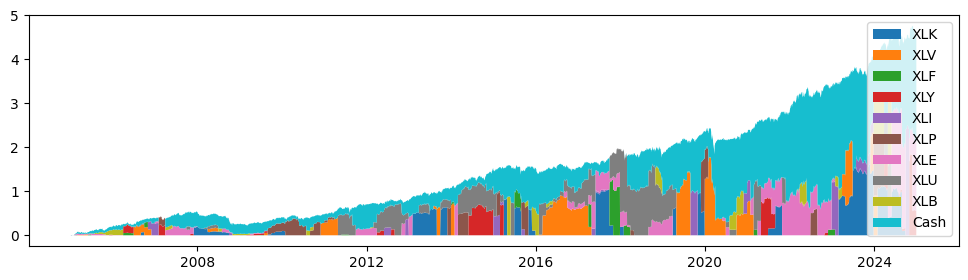

In [203]:
dl = DataLoader(db=db, tickers=sect)
m_sect = Markowitz(
    dl=dl,
    lookahead=0,
    gamma=SPREAD,
    lev=LEVERAGE,
    w_max=1.0*np.ones(dl.N),
    vc_lim=VC_LIMIT,
)
sim.run(strategy=m_sect, verbose=True)
wealth_plot(sim)

Predictor Runtime: 2024 ms
Ann Sharpe: 0.4989
Tot Ret:    1.4995
Ann Ret:    0.0469
Ann Vol:    0.0597
Max DD :    0.1098


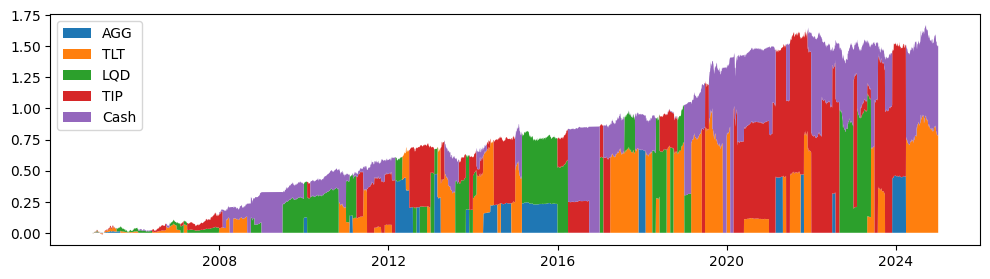

In [204]:
dl = DataLoader(db=db, tickers=bond)
m_bond = Markowitz(
    dl=dl,
    lookahead=0,
    gamma=SPREAD,
    lev=LEVERAGE,
    w_max=0.7*np.ones(dl.N),
    vc_lim=VC_LIMIT,
)
sim.run(strategy=m_bond, verbose=True)
wealth_plot(sim)

In [205]:
# dl = DataLoader(db=db, tickers=["TLK"])
# m_sect = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=0.7*np.ones(dl.N),
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=m_sect, verbose=True)
# wealth_plot(sim)

Predictor Runtime: 1603 ms
Ann Sharpe: 0.5287
Tot Ret:    2.3463
Ann Ret:    0.0623
Ann Vol:    0.085
Max DD :    0.2717


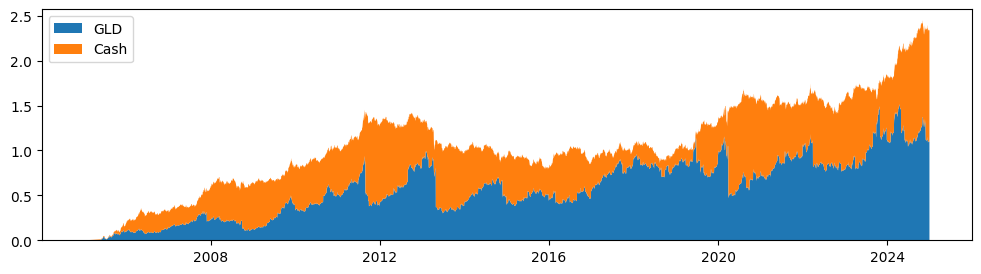

Predictor Runtime: 4712 ms
Ann Sharpe: 1.0903
Tot Ret:    2.7677
Ann Ret:    0.0687
Ann Vol:    0.0469
Max DD :    0.0888


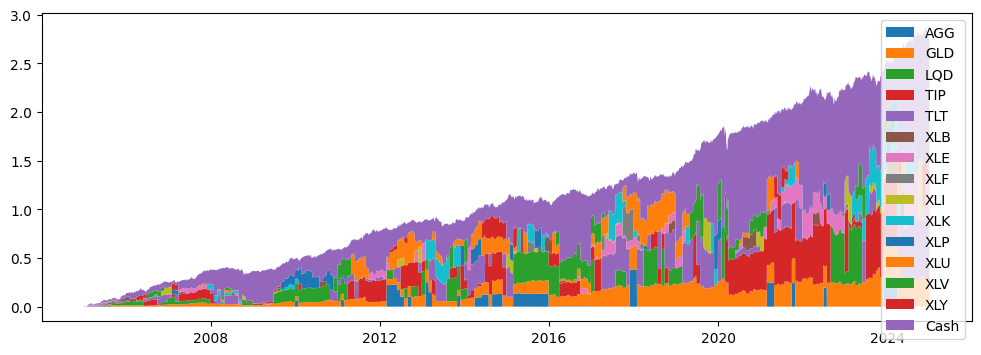

In [206]:
# sbg = ["SPY", "GLD"]
# dl = DataLoader(db=db, tickers=sbg)

# # equal_weights = np.ones(dl.N)/dl.N
# fw = FixedWeights(
#     dl=dl,
#     w_rebal=np.array([0.5, 0.5]),
#     lev=LEVERAGE,
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=fw, verbose=True)
# wealth_plot(sim)

# dl = DataLoader(db=db, tickers=sbg)
# m_sbg = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=np.array([0.7, 0.7]),
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=m_sbg, verbose=True)
# wealth_plot(sim)

VC_LIMIT = 0.08

gld = ["GLD"]
dl = DataLoader(db=db, tickers=gld)
m_gld = Markowitz(
    dl=dl,
    lookahead=0,
    gamma=SPREAD,
    lev=LEVERAGE,
    w_max=np.array([1.0]),
    vc_lim=VC_LIMIT,
)
sim.run(strategy=m_gld, verbose=True)
wealth_plot(sim)

# dl = DataLoader(db=db, tickers=["SPY"])
# m_spy = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=np.array([1.0]),
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=m_spy, verbose=True)
# wealth_plot(sim)

ms = MetaStrategy(
    db=db,
    strategies=[m_sect, m_gld, m_bond],
    w_blend=np.array([0.4, 0.2, 0.4]),
)
sim.run(strategy=ms, verbose=True)
wealth_plot(sim, figsize=(12,4))

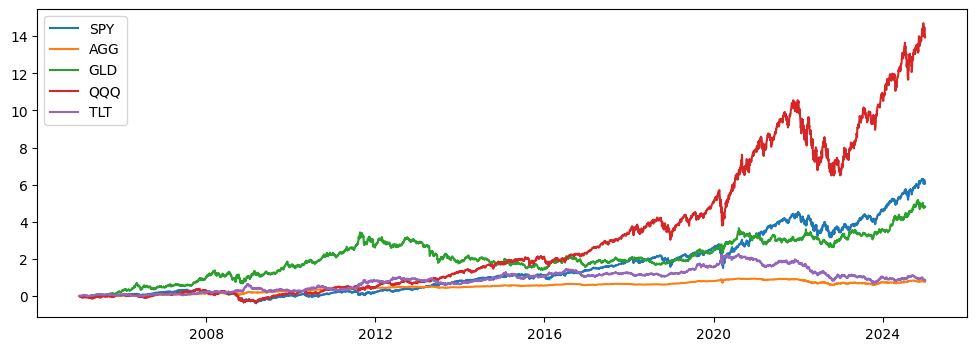

In [207]:
dl = DataLoader(
    db, ["SPY", "AGG", "GLD", "QQQ", "TLT"]
)
FIR = FIRST_DATE
D09 = "2009-01-01"
D20 = "2020-01-01"
D22 = "2022-01-01"
FIN = FINAL_DATE
asset_plot(dl, d0=FIR, d1=FIN, figsize=(12, 4))

In [208]:
# riskmodel/k10_lb6m_hc6m_hv2m.npz
# FIRST_DATE = "2005-01-03"
# FINAL_DATE = "2024-12-31"
# SPREAD = 5e-4
# LEVERAGE = 0.0
# VC_LIMIT = 0.08
# REBAL_FREQ = "M"
# m = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=np.array([0.7, 0.2, 0.7, 0.7]),
#     vc_lim=VC_LIMIT,
# )
# Backtest Runtime: 1292 ms
# Ann Sharpe: 0.8134
# Ann Ret:    0.0873
# Ann Vol:    0.0855

In [209]:
# from time import time
# start = time()
# for i in range(100):
#     run_backtest(
#         strategy=fw,
#         spread=SPREAD
#     )
# print(time() - start)

In [210]:
# tickers = ["LQD", "SMH", "XLK", "AGG"] # , "QQQ", "GLD", "AGG", "XLK"
# # tickers = ["QQQ", "AGG", "XLK"]
# for t in tickers:
#     assert t in assets_remaining

# op = mod.OptimizerParams(
#     w_prev=np.zeros(len(tickers)),
#     w_max=0.7,
#     gamma=2e-4,
#     L=0.0,
#     vc_lim=((1.08)**(1/252))-1.0,
# )

# # data_bt["alpha"] = np.ones_like(data_bt["alpha"])

# lookahead = 0  # months
# holdings: pd.DataFrame = mod.run_backtest(
#     tickers=tickers,
#     universe=rd.columns,
#     data_bt=data_bt,
#     lookahead=lookahead,
#     op=op,
#     fixed_weights=False,
# )

# # r_tot = (performance+1).prod() - 1 
# # w_avg = weights.round(3).mean(axis=0).round(3)
# # vol_ann = performance.std() * 12**0.5 * 100 # realized

# # print(f"Sharpe ratio: {sharpe:8.3f}")
# # print(f"Period return: {r_tot:7.3f}")
# # print(f"Avg weights: {w_avg}")
# # print(f"Realized vol: {vol_ann:7.3}%")
# # print(f"Period: {START_DATE} : {END_DATE}")

# nav = holdings.sum(axis=1)
# w_port = holdings.div(nav, axis=0)

# rp = nav.pct_change().dropna()
# rf = ffr["DFF"].reindex(rp.index)
# mod.sharpe_ratio(rp, rf).round(3).item()

In [211]:
# |------------.------.---.--.-|-|
#                              t 
# The first 2 years (minus a day) are lost due to lookback (trailing returns)
# The last 1 month is lost due to trying to predict the future month - no lookahead!

# # plotting thetas over time
# features_all = ["Const"] + features_ret + features_mac
# pd.DataFrame(theta.mean(axis=1), columns=features_all, index=df_ref.index).plot()
# plt.show()

# # plotting pca graph
# Am = data[assets_remaining[0]]
# Um, d, VmT = np.linalg.svd(Am)
# Um.shape, d.shape, VmT.shape
# d /= d.sum()

# plt.figure(figsize=(7,2))
# plt.plot(d.cumsum())
# plt.axhline(y=0.90, c="r")
# plt.title(f"PCA - {assets_remaining[0]}")
# # plt.axvline(x=8, c="k", ls=":")
# plt.show()

In [212]:
# NOTE Simple way of getting an alpha

# rd = rd.loc[START_DATE:END_DATE]
# rd = rd.loc[:, ~rd.isna().any(axis=0)]

# corr = rd.rolling(252).corr().dropna()
# corr_avg = corr.groupby(level=0).apply(lambda x: (x - np.eye(rd.shape[1])).mean(axis=0).abs())
# corr_avg

# ffr = ffr.reindex(rd.index)
# excess = rd.sub(ffr.values, axis=0)
# mu = excess.rolling(252).mean().dropna()
# sd = rd.rolling(252).std().dropna()
# shrp_sld = mu / sd * np.sqrt(252)

# beta = 1.0
# gamma = 1.0
# alphas = beta * shrp_sld - gamma * corr_avg
# rd = rd.reindex(alphas.index)

In [213]:
# alphas = df_prd.rank(axis=1)
# rd = rd.loc[alphas.index, assets_remaining]

# assert rd.isna().any().any() == False

# ffr = (ffr + 1)**(1/252) - 1  # transform to daily
# ffr = ffr.reindex(rd.index)
# assert ffr.isna().any().any() == False

# lookback = 42 # days
# data_bt = backtest_data(
#     alphas=alphas,
#     rd=rd,
#     ffr=ffr,
#     lookback=lookback, 
#     rebal_freq="M"
#     )
# data_bt.keys()